# 数据集预处理
针对单个数据集进行严格的：
- 设置随机种子
- 样本筛选
- 细胞质控
- 去除环境污染（是否需要？）
- 保存质控后数据至'UC/scRNA-seq_data/03_qc_filtered'文件夹
- 批次效应查看
- 降维聚类结果
- 处理异常细胞群
- 区分主要谱系

# 文件说明
- **文件名**: 6_GSE125527_tissue_qc.h5ad 
- **存放位置**: 坚果云  `UC/scRNA-seq_data/03_qc_filtered/`  
- **生成日期**: 2025-11-3  
- **生成者**: Jiang Lai
- **对应脚本**: notebooks/1_preprocessing/1.2_qc_filtered/6_GSE125527_tissue.ipynb  
- **内容说明**: 完成了针对单个数据的预处理工作，包括样本排除、细胞质控，并查看了样本间的批次效应。  

In [1]:
import numpy as np
import random
np.random.seed(42)
random.seed(42)

In [2]:
import scanpy as sc
sc.settings.verbosity = 1
print(sc.__version__)

1.9.6


/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarn

## 读取数据
GSE125527_pbmc数据集：
- 结肠直肠组织 免疫细胞
- 7UC，14HC

In [3]:
adata = sc.read_h5ad('/Users/future/Nutstore Files/UC/scRNA-seq_data/02_sample_merge/6_GSE125527_tissue.h5ad')

In [4]:
adata

AnnData object with n_obs × n_vars = 43267 × 9713
    obs: 'n_genes', 'GSM_id', 'GSM', 'id', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'n_cells'
    uns: 'REFERENCE_MANU', 'scrublet', 'status', 'status_args'

In [5]:
adata.obs.head()

,n_genes,GSM_id,GSM,id,nUMIs,mito_perc,detected_genes,cell_complexity,passing_mt,passing_nUMIs,passing_ngenes,doublet_score,predicted_doublet
GSM3576396_HC17_AAACCTGCATGGTAGG-1,1438,GSM3576396_HC17,GSM3576396,HC17,4536,0.0,1438,0.317019,True,True,True,0.104065,False
GSM3576396_HC17_AAACGGGAGATAGGAG-1,1206,GSM3576396_HC17,GSM3576396,HC17,3149,0.0,1206,0.382979,True,True,True,0.070371,False
GSM3576396_HC17_AAAGTAGAGATCACGG-1,845,GSM3576396_HC17,GSM3576396,HC17,1763,0.0,845,0.479297,True,True,True,0.029028,False
GSM3576396_HC17_AACACGTAGGTGATAT-1,2601,GSM3576396_HC17,GSM3576396,HC17,15511,0.0,2601,0.167687,True,True,True,0.086926,False
GSM3576396_HC17_AACACGTGTGTGCCTG-1,1671,GSM3576396_HC17,GSM3576396,HC17,5035,0.0,1671,0.331877,True,True,True,0.070371,False


## 处理细胞标签及分组

In [6]:
# 提取分组信息
import pandas as pd
adata.obs['group'] = adata.obs['id'].str.extract(r'([A-Za-z]+)', expand=False)
print(adata.obs[['id', 'group']].head())

                                      id group
GSM3576396_HC17_AAACCTGCATGGTAGG-1  HC17    HC
GSM3576396_HC17_AAACGGGAGATAGGAG-1  HC17    HC
GSM3576396_HC17_AAAGTAGAGATCACGG-1  HC17    HC
GSM3576396_HC17_AACACGTAGGTGATAT-1  HC17    HC
GSM3576396_HC17_AACACGTGTGTGCCTG-1  HC17    HC


`.obs`当中只保留GSM信息和分组信息

In [7]:
adata.obs.drop(columns=['GSM_id', 'id'], inplace=True)
print(adata.obs.head())

                                    n_genes         GSM  nUMIs  mito_perc  \
GSM3576396_HC17_AAACCTGCATGGTAGG-1     1438  GSM3576396   4536        0.0   
GSM3576396_HC17_AAACGGGAGATAGGAG-1     1206  GSM3576396   3149        0.0   
GSM3576396_HC17_AAAGTAGAGATCACGG-1      845  GSM3576396   1763        0.0   
GSM3576396_HC17_AACACGTAGGTGATAT-1     2601  GSM3576396  15511        0.0   
GSM3576396_HC17_AACACGTGTGTGCCTG-1     1671  GSM3576396   5035        0.0   

                                    detected_genes  cell_complexity  \
GSM3576396_HC17_AAACCTGCATGGTAGG-1            1438         0.317019   
GSM3576396_HC17_AAACGGGAGATAGGAG-1            1206         0.382979   
GSM3576396_HC17_AAAGTAGAGATCACGG-1             845         0.479297   
GSM3576396_HC17_AACACGTAGGTGATAT-1            2601         0.167687   
GSM3576396_HC17_AACACGTGTGTGCCTG-1            1671         0.331877   

                                    passing_mt  passing_nUMIs  passing_ngenes  \
GSM3576396_HC17_AAACCTGCATGGT

In [8]:
adata.obs['group'].value_counts()

group
HC    24625
UC    18642
Name: count, dtype: int64

## 样本质量查看

In [9]:
adata.obs['GSM'].value_counts()

GSM
GSM3576401    3052
GSM3576404    3039
GSM3576428    3036
GSM3576402    2786
GSM3576430    2666
GSM3576429    2600
GSM3576408    2580
GSM3576399    2577
GSM3576400    2417
GSM3576398    2412
GSM3576405    2402
GSM3576403    2369
GSM3576409    2189
GSM3576410    2074
GSM3576397    1911
GSM3576427    1132
GSM3576431    1062
GSM3576406    1028
GSM3576407     997
GSM3576426     617
GSM3576396     321
Name: count, dtype: int64

In [10]:
sample_quality_stats = adata.obs.groupby('GSM')[['n_genes', 'nUMIs', 'mito_perc']].agg(['mean', 'std', 'min', 'max'])

print(sample_quality_stats)

                n_genes                               nUMIs                    \
                   mean         std  min   max         mean          std  min   
GSM                                                                             
GSM3576396  1349.704050  642.073007  392  3414  5261.610592  4566.804517  659   
GSM3576397  1107.452643  452.867773  387  5235  4903.042386  3952.580450  622   
GSM3576398   664.112355  237.678855  384  3513  1634.721393  1167.871639  607   
GSM3576399  1027.443539  344.791394  382  2822  3045.094684  2122.276622  579   
GSM3576400   669.052544  268.333689  391  3222  1651.470004  1174.160294  539   
GSM3576401   921.053408  382.146217  382  5099  3498.278834  2706.380013  591   
GSM3576402   907.601220  337.640043  389  3137  2415.305815  1727.152625  557   
GSM3576403   983.834529  339.203222  396  3161  2535.925285  1563.040206  582   
GSM3576404   740.820336  274.231045  387  2389  2705.782494  2520.908148  586   
GSM3576405   745.661116  264

/var/folders/n6/ygb1nb55663b38zz1rbjx5lm0000gn/T/ipykernel_42363/2761774101.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_quality_stats = adata.obs.groupby('GSM')[['n_genes', 'nUMIs', 'mito_perc']].agg(['mean', 'std', 'min', 'max'])


## 细胞质控

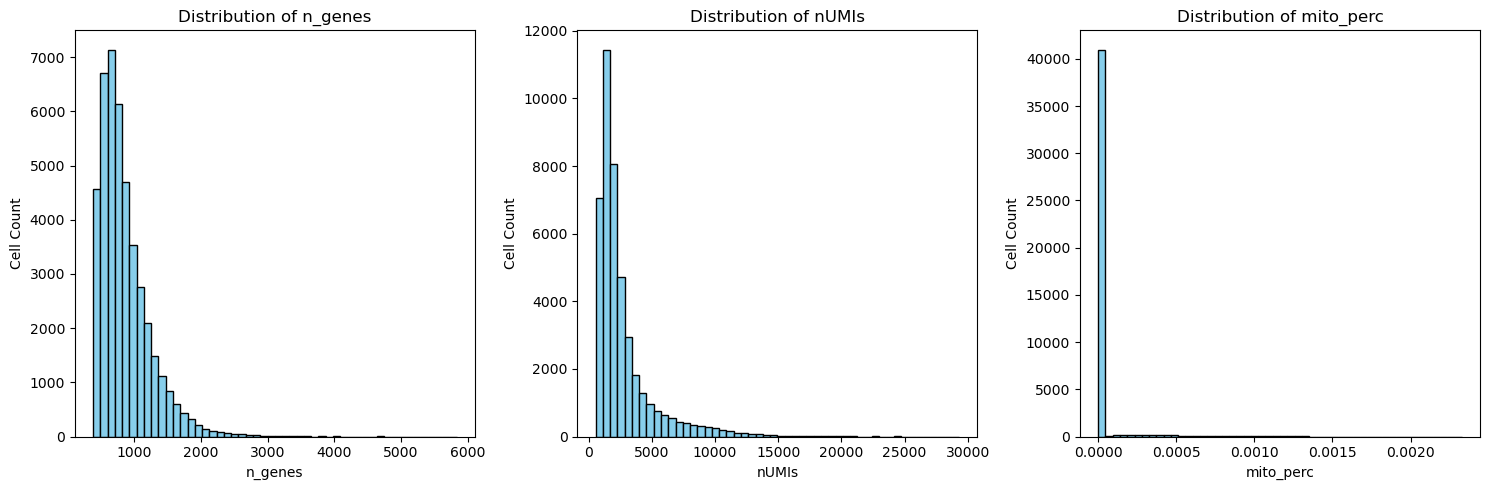

In [11]:
import matplotlib.pyplot as plt

# 选择要可视化的质量控制指标
qc_metrics = ['n_genes', 'nUMIs', 'mito_perc']

# 绘制各个指标的直方图
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# 绘制每个质量控制指标的直方图
for i, metric in enumerate(qc_metrics):
    ax[i].hist(adata.obs[metric], bins=50, color='skyblue', edgecolor='black')
    ax[i].set_title(f'Distribution of {metric}')
    ax[i].set_xlabel(metric)
    ax[i].set_ylabel('Cell Count')

# 调整布局，避免重叠
plt.tight_layout()
plt.show()


/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:840: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:840: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/var/folders/n6/ygb1nb55663b38zz1rbjx5lm0000gn/T/ipykernel_42363/2077234365.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(labels, rotation=45, ha='right')
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:840: FutureWarning: 

Passing `palette` without assigning `hue` is depreca

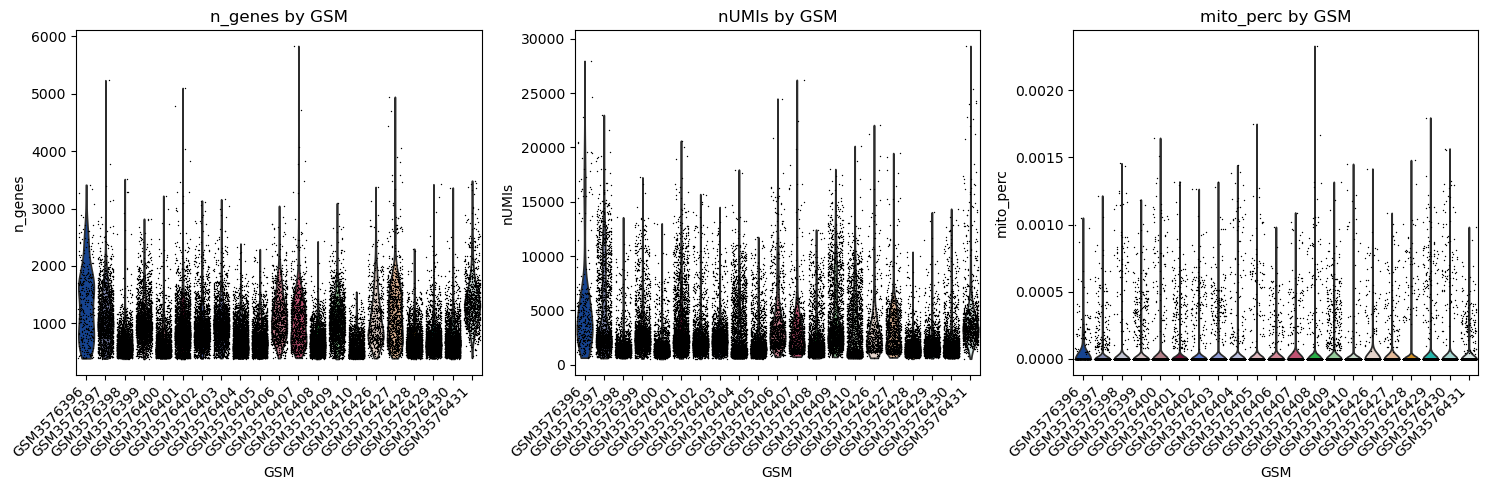

In [12]:
# 设置绘图风格
sc.settings.verbosity = 0  # 简化日志输出

# 选择要绘制的小提琴图的质量控制指标
qc_metrics = ['n_genes', 'nUMIs', 'mito_perc']

# 按照样本（GSM）绘制小提琴图
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

for i, metric in enumerate(qc_metrics):
    sc.pl.violin(adata, keys=metric, groupby='GSM', ax=ax[i], stripplot=True, jitter=0.4, show=False)
    ax[i].set_title(f'{metric} by GSM')
    ax[i].set_ylabel(f'{metric}')
    
    # 获取当前的x轴标签
    labels = ax[i].get_xticklabels()
    # 旋转标签并调整对齐方式（末尾对齐）
    ax[i].set_xticklabels(labels, rotation=45, ha='right')

# 调整布局，避免重叠
plt.tight_layout()
plt.show()


### 严格细胞质控标准
- min_genes = 200          # 最少基因数
- max_genes = 4000         # 最多基因数
- min_umis = 500           # 最少UMI数量
- max_umis = 20000         # 最多UMI数量
- max_mito_perc = 10       # 线粒体基因百分比最大值

In [13]:
# 设置阈值
min_genes = 200          # 最少基因数
max_genes = 6000         # 最多基因数
min_umis = 500           # 最少UMI数量
max_umis = 20000        # 最多UMI数量
max_mito_perc = 0.1       # 线粒体基因百分比最大值

# 根据阈值进行过滤
adata = adata[(adata.obs['n_genes'] > min_genes) & 
              (adata.obs['n_genes'] < max_genes) &
              (adata.obs['nUMIs'] > min_umis) &
              (adata.obs['nUMIs'] < max_umis) &
              (adata.obs['mito_perc'] < max_mito_perc), :]

# 输出过滤后的细胞数
print(f'Number of cells after filtering: {adata.n_obs}')

Number of cells after filtering: 43241


## 保存质控后数据


In [14]:
import os
output_dir = "/Users/future/Nutstore Files/UC/scRNA-seq_data/03_qc_filtered/"
os.makedirs(output_dir, exist_ok=True)
adata.write_h5ad(os.path.join(output_dir, "6_GSE125527_tissue_qc.h5ad"), compression='gzip')

## 降维聚类

In [ ]:
import omicverse as ov
ov.plot_set(dpi=50)
ov.settings.verbose = 1 
ov.settings.cpu_gpu_mixed_init()

血液组织细胞，所以选取2000个高变基因  
大致分别谱系，所以选取resolution=0.4

In [ ]:
# HVG
adata=ov.pp.preprocess(adata,
                       mode='shiftlog|pearson',
                       n_HVGs=2000,
                       target_sum=50*1e4)

adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]

# PCA
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

# Embedding the neighborhood graph
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='scaled|original|X_pca')

# UMAP
ov.pp.umap(adata)

# Clustering
ov.pp.leiden(adata,resolution=0.4)

In [ ]:
# 可视化查看聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'GSM', 'group'],
                frameon='small',
                wspace=0.5)

In [ ]:
# 免疫谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['PTPRC', 'CD3D', 'CD19', 'CD68'], 
                frameon='small')

## 去除批次效应
按样本去除批次，看看是否效果会更好

使用`harmony`

In [ ]:
ov.single.batch_correction(adata,
                           batch_key='GSM', # 去批次分组标签
                           methods='harmony',
                           n_pcs=50)
                           
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='X_harmony')

ov.pp.umap(adata)

ov.pp.leiden(adata,resolution=0.4)

In [ ]:
# 可视化查看去除批次效应后聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'GSM', 'group'],
                frameon='small',
                wspace=0.5)

In [ ]:
# 免疫谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['PTPRC', 'CD3D', 'CD19', 'CD68'], 
                frameon='small')

## GPT自动注释

In [ ]:
# 获取每个细胞群的基因
all_markers = ov.single.get_celltype_marker(adata,
                                            clustertype='leiden',
                                            rank=True,
                                            key='rank_genes_groups',
                                            foldchange=1,
                                            topgenenumber=10)
all_markers

In [ ]:
os.environ['AGI_API_KEY'] = 'sk-ff0dc715f640466393e6aa71c9da6848'
result = ov.single.gptcelltype(all_markers,
                               tissuename='colon',
                               speciename='human',
                               model='qwen-plus',
                               provider='qwen',
                               topgenenumber=10)
result

In [ ]:
# 添加识别结果到obs
adata.obs['gpt_celltype'] = adata.obs['leiden'].map(result).astype('category')

In [ ]:
# 可视化查看结果
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'gpt_celltype'],
                # legend_loc='on data',
                frameon='small',
                legend_fontoutline=0.5,
                palette=ov.utils.palette()[10:],
                wspace=0.3)

In [ ]:
# 统计每种细胞类型数量及占比
celltype_counts = adata.obs['gpt_celltype'].value_counts(normalize=True) * 100
print(celltype_counts)